In [554]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import difflib
import re
from scipy.stats import pearsonr, ks_2samp, fisher_exact



Load data

In [555]:
# Load the AnnData object from the .h5ad file
adata = sc.read("PBMC_combined_annotated_3data.h5ad") #this data is log1p, not scaled
adata = adata[adata.obs['source'].isin(['SSTX', 'SSTX-pA+'])].copy()

In [556]:
adata

AnnData object with n_obs × n_vars = 39036 × 37228
    obs: 'source', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_doublet2', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_res_0.02', 'leiden_res_0.10', 'leiden_res_0.50', 'leiden_res_1.00', 'leiden_res_1.25', 'leiden_res_1.50', 'leiden_res_1.75', 'leiden_res_2.00', 'leiden_res_2.50', 'cell_type_lvl1', 'cell_type_lvl0', 'cell_type_lvl2'
    var: 'gene_ids', 'gene_id', 'biotype', 'n_cells', 'gene_names', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mt', 'highly_variable'
    uns: 'cell_type_lvl0_colors', 'cell_type_lvl1_colors', 'leiden', 'leiden_res_0.02', 'leiden_res_0.02_colors', 'leiden_res_0.10', 'leiden_res_0.10_colors', 'leiden_res_0.50', 'leiden_res_0.50_colors', 'leiden_res_1.00', 'leiden_res_1.00_colors', 'leiden_res_1.25', 'leiden_res_1.25_colors', 'leiden_res_1.50', 'leiden_res_1.50_colors', 'leiden_res_1.75', 'leiden_res_1.75_colors',

(extra) Look for expressed miRNAs

In [557]:
# --- 1. Identify miRNAs by biotype ---
is_mirna = adata.var["biotype"] == "miRNA"
mirna_genes = adata.var.index[is_mirna]

print(f"Number of miRNA features: {len(mirna_genes)}")
print("Example miRNAs:", mirna_genes[:20].tolist())


Number of miRNA features: 648
Example miRNAs: ['ENSG00000278791', 'MIR6727', 'MIR6808', 'MIR6728', 'ENSG00000264881', 'MIR6729', 'MIR7846', 'MIR4632', 'MIR6084', 'MIR3115', 'ENSG00000266802', 'MIR6731', 'MIR4425', 'MIR3917', 'MIR1976', 'MIR4420', 'MIR5585', 'MIR3605', 'MIR6732', 'MIR30E']


In [558]:
# --- 2. Extract expression matrix for these miRNAs ---
Xm = adata[:, mirna_genes].X
if sp.issparse(Xm):
    Xm = Xm.toarray()

# --- 3. Compute basic detection stats ---
cells_detected = (Xm > 0).sum(axis=0)
mean_expr = Xm.mean(axis=0)   # depends on your normalization (often log1p)

mirna_stats = (
    pd.DataFrame({
        "mirna": mirna_genes,
        "cells_detected": cells_detected,
        "frac_cells": cells_detected / adata.n_obs,
        "mean_expr": mean_expr,
    })
    .sort_values("cells_detected", ascending=False)
    .reset_index(drop=True)
)

mirna_stats.head(100)

,mirna,cells_detected,frac_cells,mean_expr
0,MIR4426,15935,0.408213,0.680184
1,MIR4709,8222,0.210626,0.298786
2,MIR1244-1,6999,0.179296,0.257332
3,MIR6821,4297,0.110078,0.155334
4,MIR7705,3101,0.079439,0.105931
...,...,...,...,...
95,MIR4521,57,0.001460,0.001942
96,MIR636,57,0.001460,0.002311
97,MIR6084,56,0.001435,0.002046
98,MIR4487,56,0.001435,0.001536


Filter miRNAs by Expression

In [559]:
# Calculate fraction of cells expressing each miRNA per cell type
cell_types = adata.obs["cell_type_lvl2"].unique()
mirna_genes = adata.var_names[adata.var["biotype"] == "miRNA"]

keep_mirnas = set()
for ct in cell_types:
    ct_mask = adata.obs["cell_type_lvl2"] == ct
    n_cells = ct_mask.sum()
    if n_cells < 10: continue # Skip rare cell types

    # Calculate fraction expressed
    X_ct = adata[ct_mask, mirna_genes].X
    if sp.issparse(X_ct):
        X_ct = X_ct.tocsc() # Efficient column slicing
    
    detected = (X_ct > 0).sum(axis=0)
    if hasattr(detected, "A1"): detected = detected.A1
    else: detected = np.ravel(detected)
    
    frac = detected / n_cells
    keep_mirnas.update(mirna_genes[frac > 0.015])

print(f"Total miRNAs: {len(mirna_genes)}")
print(f"miRNAs expressed >1.5% in at least one cell type: {len(keep_mirnas)}")

# Additional filter: must be present in at least 100 cells across dataset
filtered_mirnas = set()
for mirna in keep_mirnas:
    mirna_expr = adata[:, mirna].X
    if sp.issparse(mirna_expr):
        mirna_expr = mirna_expr.toarray()
    n_cells = (mirna_expr > 0).sum()
    if n_cells >= 100:
        filtered_mirnas.add(mirna)

print(f"miRNAs after 100-cell filter: {len(filtered_mirnas)}")
keep_mirnas = filtered_mirnas

keep_mirnas = sorted(list(keep_mirnas))
# Print cell count statistics for kept miRNAs
print(f"\nCell count statistics for {len(keep_mirnas)} kept miRNAs:")
print(f"Total cells in dataset: {adata.n_obs}")
print("\nExample miRNAs (first 10):")
for mirna in keep_mirnas[:10]:
    mirna_expr = adata[:, mirna].X
    if sp.issparse(mirna_expr):
        mirna_expr = mirna_expr.toarray()
    n_cells = (mirna_expr > 0).sum()
    pct_cells = 100 * n_cells / adata.n_obs
    print(f"  {mirna}: {n_cells} cells ({pct_cells:.1f}%)")
print(f"  ... (showing first 10 of {len(keep_mirnas)} miRNAs)")

Total miRNAs: 648
miRNAs expressed >1.5% in at least one cell type: 77
miRNAs after 100-cell filter: 51

Cell count statistics for 51 kept miRNAs:
Total cells in dataset: 39036

Example miRNAs (first 10):
  ENSG00000266802: 316 cells (0.8%)
  ENSG00000275110: 802 cells (2.1%)
  ENSG00000278791: 277 cells (0.7%)
  MIR1181: 599 cells (1.5%)
  MIR1244-1: 6999 cells (17.9%)
  MIR142: 658 cells (1.7%)
  MIR147B: 161 cells (0.4%)
  MIR150: 922 cells (2.4%)
  MIR21: 169 cells (0.4%)
  MIR2110: 177 cells (0.5%)
  ... (showing first 10 of 51 miRNAs)


In [560]:
print("\nExample miRNAs :")
for mirna in keep_mirnas:
    mirna_expr = adata[:, mirna].X
    if sp.issparse(mirna_expr):
        mirna_expr = mirna_expr.toarray()
    n_cells = (mirna_expr > 0).sum()
    pct_cells = 100 * n_cells / adata.n_obs
    print(f"  {mirna}: {n_cells} cells ({pct_cells:.1f}%)")
print(f"  ... (showing first 10 of {len(keep_mirnas)} miRNAs)")


Example miRNAs :
  ENSG00000266802: 316 cells (0.8%)
  ENSG00000275110: 802 cells (2.1%)
  ENSG00000278791: 277 cells (0.7%)
  MIR1181: 599 cells (1.5%)
  MIR1244-1: 6999 cells (17.9%)
  MIR142: 658 cells (1.7%)
  MIR147B: 161 cells (0.4%)
  MIR150: 922 cells (2.4%)
  MIR21: 169 cells (0.4%)
  MIR2110: 177 cells (0.5%)
  MIR222: 755 cells (1.9%)
  MIR223: 526 cells (1.3%)
  MIR29B2: 275 cells (0.7%)
  MIR3188: 341 cells (0.9%)
  MIR3190: 198 cells (0.5%)
  MIR3195: 183 cells (0.5%)
  MIR320A: 438 cells (1.1%)
  MIR326: 520 cells (1.3%)
  MIR3615: 1198 cells (3.1%)
  MIR3652: 1646 cells (4.2%)
  MIR3654: 2956 cells (7.6%)
  MIR3655: 1514 cells (3.9%)
  MIR3658: 125 cells (0.3%)
  MIR3945: 659 cells (1.7%)
  MIR423: 191 cells (0.5%)
  MIR4426: 15935 cells (40.8%)
  MIR4442: 102 cells (0.3%)
  MIR4444-1: 252 cells (0.6%)
  MIR4449: 152 cells (0.4%)
  MIR4647: 308 cells (0.8%)
  MIR4651: 426 cells (1.1%)
  MIR4680: 153 cells (0.4%)
  MIR4709: 8222 cells (21.1%)
  MIR4751: 107 cells (0.3%)

In [561]:
# Check for canonical immune miRNAs in the FILTERED list
canonical_immune_mirnas = [
    # General hematopoietic
    "MIR142", "MIR150", "MIR223", "MIR144", "MIR451A",
    
    # Monocyte/macrophage / inflammatory
    "MIR155", "MIR146A", "MIR146B", "MIR21", "MIR125B",
    "MIR147A", "MIR222", "MIR221", "MIR24", "MIR27A", "MIR27B",
    "MIR26A1", "MIR26B", "MIR29A", "MIR29B1", "MIR29C",

    # T-cell / NK / lymphocyte
    "MIR31", "MIR181A1", "MIR181A2", "MIR181B1", "MIR181C",
    "MIR17", "MIR20A", "MIR19A", "MIR19B1", "MIR92A1",
    "MIR130A", "MIR130B", "MIR221", "MIR222",
    "MIRLET7A", "MIRLET7B", "MIRLET7C", "MIRLET7D", "MIRLET7F2",
    
    # B-cell
    "MIR150", "MIR342", "MIR148A", "MIR210", "MIR34A", "MIR34C",

    # Dendritic cell / antiviral
    "MIR155HG", "MIR22", "MIR29A", "MIR21", "MIR147B",

    # Neutrophil / granulocyte lineage (might be low in PBMC)
    "MIR223", "MIR451A", "MIR23A", "MIR24", "MIR27A", "MIR27B",

    # Additional known immune miRNAs
    "MIR1307", "MIR363", "MIR101", "MIR103B1", "MIR191", "MIR320A",
]

canon_present = [m for m in canonical_immune_mirnas if m in keep_mirnas]
canon_missing = [m for m in canonical_immune_mirnas if m not in keep_mirnas]

print("Present canonical immune miRNAs (>2% in at least one cell type):", canon_present)
print("Missing or low abundance:", canon_missing[:20], "...")

Present canonical immune miRNAs (>2% in at least one cell type): ['MIR142', 'MIR150', 'MIR223', 'MIR21', 'MIR222', 'MIR222', 'MIR150', 'MIR21', 'MIR147B', 'MIR223', 'MIR320A']
Missing or low abundance: ['MIR144', 'MIR451A', 'MIR155', 'MIR146A', 'MIR146B', 'MIR125B', 'MIR147A', 'MIR221', 'MIR24', 'MIR27A', 'MIR27B', 'MIR26A1', 'MIR26B', 'MIR29A', 'MIR29B1', 'MIR29C', 'MIR31', 'MIR181A1', 'MIR181A2', 'MIR181B1'] ...


Load Predicted Targets

In [562]:
targets_file = "Predicted_Targets_Context_Scores.default_predictions.txt"
df_targets = pd.read_csv(targets_file, sep="\t")

# Filter for human
df_targets = df_targets[df_targets["Gene Tax ID"] == 9606].copy()

print("Sample raw miRNA names from file:", df_targets["miRNA"].head().tolist())

# Map miRNA names
def map_mirna_name(name):
    # e.g. hsa-miR-23a-3p -> MIR23A
    # e.g. hsa-let-7a-5p -> MIRLET7A
    
    if not isinstance(name, str): return None
    
    parts = name.split("-")
    # parts[0] = hsa
    # parts[1] = miR or let
    # parts[2] = family/member
    
    if len(parts) < 3: return None
    
    prefix = parts[1].upper()
    suffix = parts[2].upper()
    
    if prefix == "MIR":
        new_name = "MIR" + suffix
    elif prefix == "LET":
        new_name = "MIRLET" + suffix
    else:
        return None
        
    return new_name

df_targets["miRNA_mapped"] = df_targets["miRNA"].apply(map_mirna_name)

# Create a mapping from mapped name to original names
mapped_to_raw = df_targets.groupby("miRNA_mapped")["miRNA"].unique().to_dict()

# Create a dictionary of targets (using mapped names)
mirna_to_targets = df_targets.groupby("miRNA_mapped")["Gene Symbol"].unique().to_dict()

# --- Refined Matching Logic (Suffix Stripping) ---
print("\n--- Resolving Unmatched miRNAs with Suffix Stripping ---")
final_mirna_to_targets = {}
matched_count = 0
suffix_matched_count = 0
unmatched_list = []
matched_details_list = []

for m in keep_mirnas:
    # 1. Exact Match
    if m in mirna_to_targets:
        final_mirna_to_targets[m] = mirna_to_targets[m]
        matched_count += 1
        # Record for verification
        raw_names = mapped_to_raw.get(m, [])
        raw_str = ", ".join(raw_names[:3])
        if len(raw_names) > 3: raw_str += "..."
        matched_details_list.append(f"Matched: {m} -> {m} (from {raw_str})")
    else:
        # 2. Suffix Stripping (e.g. MIR101-1 -> MIR101)
        # Remove -1, -2, 1, 2, etc. from the end
        # Regex: matches -digit or digit at the end
        stripped = re.sub(r'[-]?\d+$', '', m)
        
        if stripped != m and stripped in mirna_to_targets:
            final_mirna_to_targets[m] = mirna_to_targets[stripped]
            suffix_matched_count += 1
            # Record for verification
            raw_names = mapped_to_raw.get(stripped, [])
            raw_str = ", ".join(raw_names[:3])
            if len(raw_names) > 3: raw_str += "..."
            matched_details_list.append(f"Matched: {m} -> {stripped} (from {raw_str})")
        else:
            unmatched_list.append(m)

print(f"\nTotal kept miRNAs: {len(keep_mirnas)}")
print(f"Exact matches: {matched_count}")
print(f"Suffix stripped matches: {suffix_matched_count}")
print(f"Still unmatched: {len(unmatched_list)}")

# --- Print ALL Matched Details for Verification ---
print("\n--- Full Match Verification List ---")
for detail in matched_details_list:
    print(detail)

# --- Closest Match Suggestions for Remaining Unmatched ---
print("\n--- Closest Match Suggestions for Remaining Unmatched ---")
all_target_mirnas = list(mirna_to_targets.keys())
for m in unmatched_list[:20]: # Check first 20 unmatched
    matches = difflib.get_close_matches(m, all_target_mirnas, n=3, cutoff=0.6)
    if matches:
        # Get original names for the matches
        match_details = []
        for match in matches:
            raw_names = mapped_to_raw.get(match, [])
            # Limit to first 2 raw names to keep it brief
            raw_str = ", ".join(raw_names[:2])
            if len(raw_names) > 2: raw_str += "..."
            match_details.append(f"{match} (from {raw_str})")
        print(f"{m} -> {match_details}")

# Update the main dictionary to use the resolved one
mirna_to_targets = final_mirna_to_targets

# Filter targets to those in our gene list
valid_genes = set(adata.var_names)
# (Note: we already filtered df_targets by gene list in previous steps in original code, 
# but here we are using the dictionary directly. Let's ensure targets are valid)
for m in mirna_to_targets:
    mirna_to_targets[m] = [g for g in mirna_to_targets[m] if g in valid_genes]

Sample raw miRNA names from file: ['hsa-miR-23c', 'hsa-miR-23b-3p', 'hsa-miR-23a-3p', 'hsa-miR-7-5p', 'hsa-miR-30b-5p']

--- Resolving Unmatched miRNAs with Suffix Stripping ---

Total kept miRNAs: 51
Exact matches: 10
Suffix stripped matches: 2
Still unmatched: 39

--- Full Match Verification List ---
Matched: MIR142 -> MIR142 (from hsa-miR-142-5p, hsa-miR-142-3p.1, hsa-miR-142-3p.2)
Matched: MIR147B -> MIR147B (from hsa-miR-147b)
Matched: MIR150 -> MIR150 (from hsa-miR-150-5p)
Matched: MIR21 -> MIR21 (from hsa-miR-21-5p)
Matched: MIR222 -> MIR222 (from hsa-miR-222-3p)
Matched: MIR223 -> MIR223 (from hsa-miR-223-3p)
Matched: MIR29B2 -> MIR29B (from hsa-miR-29b-3p)
Matched: MIR320A -> MIR320A (from hsa-miR-320a)
Matched: MIR326 -> MIR326 (from hsa-miR-326)
Matched: MIR423 -> MIR423 (from hsa-miR-423-5p, hsa-miR-423-3p)
Matched: MIRLET7F1 -> MIRLET7F (from hsa-let-7f-5p)
Matched: MIRLET7I -> MIRLET7I (from hsa-let-7i-5p)

--- Closest Match Suggestions for Remaining Unmatched ---
MIR1181

Load Nonconserved Predicted Targets (Additional)

In [563]:
# Load nonconserved predicted targets to supplement the conserved ones
nonconserved_file = "Nonconserved_Family_Info_human.txt"

try:
    # Read the file
    df_noncons = pd.read_csv(nonconserved_file, sep="\t")
    
    print(f"Loaded {len(df_noncons)} total rows from nonconserved file")
    
    if "Species ID" in df_noncons.columns:
        df_noncons = df_noncons[df_noncons["Species ID"] == 9606].copy()
        print(f"After filtering for human (9606): {len(df_noncons)} rows")
    
    # Simple mapping function for nonconserved file format
    def map_noncons_mirna(name):
        """Convert miR-1181 to MIR1181 format"""
        if pd.isna(name):
            return None
        # Remove 'miR-' or 'mir-' prefix and convert to uppercase
        name = str(name).strip()
        if name.lower().startswith('mir-'):
            name = name[4:]  # Remove 'miR-' or 'mir-'
        # Add MIR prefix and uppercase
        return 'MIR' + name.upper()
    
    # Process miRNA families - handle slash-separated families
    def expand_mirna_family(family_str):
        """
        Expand miRNA families like 'miR-641/3617-5p' into individual miRNAs.
        Returns a list of individual miRNA names.
        """
        if '/' not in family_str:
            return [family_str]
        
        # Split by slash
        parts = family_str.split('/')
        
        # Check if there's a common suffix (like -5p or -3p)
        suffix = ''
        if parts[-1].endswith(('-5p', '-3p', '-1', '-2')):
            # Extract suffix from last part
            for s in ['-5p', '-3p', '-1', '-2']:
                if parts[-1].endswith(s):
                    suffix = s
                    parts[-1] = parts[-1][:-len(s)]
                    break
        
        # Reconstruct individual miRNAs
        mirnas = []
        for part in parts:
            if part.startswith('miR-'):
                mirnas.append(part + suffix)
            else:
                mirnas.append('miR-' + part + suffix)
        
        return mirnas
    
    # Expand families and create mapping
    expanded_rows = []
    for idx, row in df_noncons.iterrows():
        family = row["miR Family"]
        gene = row["Gene Symbol"]
        
        # Expand the family
        individual_mirnas = expand_mirna_family(family)
        
        for mirna in individual_mirnas:
            expanded_rows.append({
                'miRNA': mirna,
                'Gene Symbol': gene
            })
    
    df_noncons_expanded = pd.DataFrame(expanded_rows)
    print(f"Expanded to {len(df_noncons_expanded)} individual miRNA-target pairs")
    
    # Show sample before mapping
    print(f"Sample raw miRNA names: {df_noncons_expanded['miRNA'].unique()[:5].tolist()}")
    
    # Map miRNA names using the simpler function
    df_noncons_expanded["miRNA_mapped"] = df_noncons_expanded["miRNA"].apply(map_noncons_mirna)
    
    # Remove None values
    df_noncons_expanded = df_noncons_expanded[df_noncons_expanded["miRNA_mapped"].notna()].copy()
    
    # Show sample after mapping
    print(f"Sample mapped miRNA names: {df_noncons_expanded['miRNA_mapped'].unique()[:5].tolist()}")
    
    # Create mapping
    noncons_mapped_to_raw = df_noncons_expanded.groupby("miRNA_mapped")["miRNA"].unique().to_dict()
    mirna_to_noncons_raw = df_noncons_expanded.groupby("miRNA_mapped")["Gene Symbol"].unique().to_dict()
    
    print(f"Mapped to {len(mirna_to_noncons_raw)} unique miRNA names")
    
    # Check for specific example
    if "MIR1181" in mirna_to_noncons_raw:
        print(f"Example: MIR1181 has {len(mirna_to_noncons_raw['MIR1181'])} targets")
    
    # --- Merge with existing predicted targets ---
    print("\n--- Merging Nonconserved Targets with Conserved Targets ---")
    
    # Track statistics
    n_already_had = 0
    n_newly_added = 0
    n_targets_added = 0
    matched_examples = []
    
    print(f"miRNAs with conserved targets before merge: {len(mirna_to_targets)}")
    print(f"Total kept miRNAs to check: {len(keep_mirnas)}")
    
    for m in keep_mirnas:
        # Check if this miRNA already has targets from conserved predictions
        if m in mirna_to_targets and len(mirna_to_targets[m]) > 0:
            n_already_had += 1
            continue
        
        # Try to find in nonconserved - exact match first
        if m in mirna_to_noncons_raw:
            targets = [g for g in mirna_to_noncons_raw[m] if g in valid_genes]
            if len(targets) > 0:
                mirna_to_targets[m] = targets
                n_newly_added += 1
                n_targets_added += len(targets)
                if len(matched_examples) < 5:
                    matched_examples.append(f"{m}: {len(targets)} targets")
        else:
            # Try suffix stripping
            stripped = re.sub(r'[-]?\d+$', '', m)
            if stripped != m and stripped in mirna_to_noncons_raw:
                targets = [g for g in mirna_to_noncons_raw[stripped] if g in valid_genes]
                if len(targets) > 0:
                    mirna_to_targets[m] = targets
                    n_newly_added += 1
                    n_targets_added += len(targets)
                    if len(matched_examples) < 5:
                        matched_examples.append(f"{m} -> {stripped}: {len(targets)} targets")
    
    print(f"miRNAs that already had conserved targets: {n_already_had}")
    print(f"miRNAs newly matched from nonconserved: {n_newly_added}")
    print(f"Total new target predictions added: {n_targets_added}")
    print(f"\nExamples of newly matched:")
    for ex in matched_examples:
        print(f"  {ex}")
    print(f"\nTotal miRNAs with predicted targets (conserved + nonconserved): {len(mirna_to_targets)}")
    
except FileNotFoundError:
    print(f"Nonconserved targets file '{nonconserved_file}' not found. Skipping.")
except Exception as e:
    print(f"Error loading nonconserved targets: {e}")
    import traceback
    traceback.print_exc()


Loaded 9888133 total rows from nonconserved file
After filtering for human (9606): 9888133 rows
Expanded to 12110863 individual miRNA-target pairs
Sample raw miRNA names: ['miR-708-3p', 'miR-4511', 'miR-641-5p', 'miR-3617-5p', 'miR-3667-5p']
Sample mapped miRNA names: ['MIR708-3P', 'MIR4511', 'MIR641-5P', 'MIR3617-5P', 'MIR3667-5P']
Mapped to 2151 unique miRNA names
Example: MIR1181 has 178 targets

--- Merging Nonconserved Targets with Conserved Targets ---
miRNAs with conserved targets before merge: 12
Total kept miRNAs to check: 51
miRNAs that already had conserved targets: 12
miRNAs newly matched from nonconserved: 27
Total new target predictions added: 67151

Examples of newly matched:
  MIR1181: 152 targets
  MIR1244-1 -> MIR1244: 2314 targets
  MIR2110: 4883 targets
  MIR3188: 3850 targets
  MIR3195: 361 targets

Total miRNAs with predicted targets (conserved + nonconserved): 39


Load Validated Targets

In [564]:
validated_file = "hsa_MTI.csv"
try:
    df_validated = pd.read_csv(validated_file)
    
    # Filter for human targets (if column exists, otherwise assume file is hsa specific)
    if "Species (Target Gene)" in df_validated.columns:
        df_validated = df_validated[df_validated["Species (Target Gene)"] == "hsa"].copy()
        
    # Filter for Functional MTI
    if "Support Type" in df_validated.columns:
        df_validated = df_validated[df_validated["Support Type"] == "Functional MTI"].copy()
        
    # Map miRNA names
    df_validated["miRNA_mapped"] = df_validated["miRNA"].apply(map_mirna_name)
    
    # Create a mapping from mapped name to original names for validated
    val_mapped_to_raw = df_validated.groupby("miRNA_mapped")["miRNA"].unique().to_dict()
    
    # Create dictionary
    mirna_to_validated_raw = df_validated.groupby("miRNA_mapped")["Target Gene"].unique().to_dict()
    
    # --- Refined Matching Logic for Validated (with detailed output) ---
    print("\n--- Matching Validated Targets to Expressed miRNAs ---")
    final_mirna_to_validated = {}
    matched_count = 0
    suffix_matched_count = 0
    unmatched_list = []
    matched_details_list = []
    
    for m in keep_mirnas:
        # 1. Exact Match
        if m in mirna_to_validated_raw:
            final_mirna_to_validated[m] = mirna_to_validated_raw[m]
            matched_count += 1
            # Record for verification
            raw_names = val_mapped_to_raw.get(m, [])
            raw_str = ", ".join(raw_names[:3])
            if len(raw_names) > 3: raw_str += "..."
            matched_details_list.append(f"Matched: {m} -> {m} (from {raw_str})")
        else:
            # 2. Suffix Stripping
            stripped = re.sub(r'[-]?\d+$', '', m)
            if stripped != m and stripped in mirna_to_validated_raw:
                final_mirna_to_validated[m] = mirna_to_validated_raw[stripped]
                suffix_matched_count += 1
                # Record for verification
                raw_names = val_mapped_to_raw.get(stripped, [])
                raw_str = ", ".join(raw_names[:3])
                if len(raw_names) > 3: raw_str += "..."
                matched_details_list.append(f"Matched: {m} -> {stripped} (from {raw_str})")
            else:
                unmatched_list.append(m)
    
    mirna_to_validated = final_mirna_to_validated
    
    # Filter targets to those in our gene list
    for m in mirna_to_validated:
        mirna_to_validated[m] = [g for g in mirna_to_validated[m] if g in valid_genes]
        
    print(f"\nTotal kept miRNAs: {len(keep_mirnas)}")
    print(f"Exact matches: {matched_count}")
    print(f"Suffix-stripped matches: {suffix_matched_count}")
    print(f"Unmatched: {len(unmatched_list)}")
    print(f"\n--- Matched miRNA Details (first 50) ---")
    for detail in matched_details_list[:50]:
        print(detail)
    
    # --- Closest Match Suggestions for Remaining Unmatched ---
    print("\n--- Closest Match Suggestions for Unmatched miRNAs ---")
    all_validated_mirnas = list(mirna_to_validated_raw.keys())
    for m in unmatched_list[:20]:  # Check first 20 unmatched
        matches = difflib.get_close_matches(m, all_validated_mirnas, n=3, cutoff=0.6)
        if matches:
            # Get original names for the matches
            match_details = []
            for match in matches:
                raw_names = val_mapped_to_raw.get(match, [])
                raw_str = ", ".join(raw_names[:3])
                if len(raw_names) > 3: raw_str += "..."
                match_details.append(f"{match} (from {raw_str})")
            print(f"{m} -> {match_details}")
    
    print(f"\nValidated targets loaded. Mapped to {len(mirna_to_validated)} miRNAs.")
    
except FileNotFoundError:
    print("Validated targets file not found. Skipping.")
    mirna_to_validated = {}



--- Matching Validated Targets to Expressed miRNAs ---

Total kept miRNAs: 51
Exact matches: 22
Suffix-stripped matches: 2
Unmatched: 27

--- Matched miRNA Details (first 50) ---
Matched: MIR1181 -> MIR1181 (from hsa-miR-1181)
Matched: MIR142 -> MIR142 (from hsa-miR-142-3p, hsa-miR-142-5p)
Matched: MIR147B -> MIR147B (from hsa-miR-147b)
Matched: MIR150 -> MIR150 (from hsa-miR-150-5p, rno-miR-150-5p, hsa-miR-150-3p)
Matched: MIR21 -> MIR21 (from hsa-miR-21-5p, hsa-miR-21-3p, rno-miR-21-5p...)
Matched: MIR222 -> MIR222 (from hsa-miR-222-3p, hsa-miR-222-5p)
Matched: MIR223 -> MIR223 (from hsa-miR-223-3p, hsa-miR-223-5p)
Matched: MIR29B2 -> MIR29B (from hsa-miR-29b-3p, hsa-miR-29b-1-5p, hsa-miR-29b-2-5p)
Matched: MIR3188 -> MIR3188 (from hsa-miR-3188)
Matched: MIR320A -> MIR320A (from hsa-miR-320a)
Matched: MIR326 -> MIR326 (from hsa-miR-326)
Matched: MIR3658 -> MIR3658 (from hsa-miR-3658)
Matched: MIR423 -> MIR423 (from hsa-miR-423-3p, hsa-miR-423-5p)
Matched: MIR4449 -> MIR4449 (from hs

Minibulk Correlation Analysis

In [565]:
# Select protein coding genes for correlation
coding_genes = adata.var_names[adata.var["biotype"] == "protein_coding"]

# Filter targets by expression - only keep genes expressed in >1% cells AND mean expr >0.1
print("Filtering targets by expression...")
# Calculate expression fraction (presence in cells)
expressed_mask = (X_coding > 0).sum(axis=0)
if hasattr(expressed_mask, "A1"): expressed_mask = expressed_mask.A1
else: expressed_mask = np.ravel(expressed_mask)
expressed_frac = expressed_mask / adata.n_obs

# Calculate mean expression level
mean_expr = X_coding.mean(axis=0)
if hasattr(mean_expr, "A1"): mean_expr = mean_expr.A1
else: mean_expr = np.ravel(mean_expr)

# Apply both filters: >1% cells AND mean expression > 0.1
expressed_genes = set(coding_genes[(expressed_frac > 0.01) & (mean_expr > 0.1)])
print(f"Genes expressed in >1% cells: {(expressed_frac > 0.01).sum()} / {len(coding_genes)}")
print(f"Genes with mean expression >0.1: {(mean_expr > 0.1).sum()} / {len(coding_genes)}")
print(f"Genes passing both filters: {len(expressed_genes)} / {len(coding_genes)}")

# Filter target dictionaries to only include expressed genes
mirna_to_targets_expressed = {}
mirna_to_validated_expressed = {}

for mirna, targets in mirna_to_targets.items():
    expressed_targets = [t for t in targets if t in expressed_genes]
    if len(expressed_targets) > 0:
        mirna_to_targets_expressed[mirna] = expressed_targets

for mirna, targets in mirna_to_validated.items():
    expressed_targets = [t for t in targets if t in expressed_genes]
    if len(expressed_targets) > 0:
        mirna_to_validated_expressed[mirna] = expressed_targets

print(f"miRNAs with expressed predicted targets: {len(mirna_to_targets_expressed)}")
print(f"miRNAs with expressed validated targets: {len(mirna_to_validated_expressed)}")

# Use filtered dictionaries for analysis
mirna_to_targets = mirna_to_targets_expressed
mirna_to_validated = mirna_to_validated_expressed
X_coding = adata[:, coding_genes].X
if sp.issparse(X_coding): X_coding = X_coding.tocsr()

# Import t-distribution for p-value calculation
from scipy.stats import t, ks_2samp, fisher_exact

results = []

# Union of all miRNAs (predicted or validated)
all_mirnas = set(mirna_to_targets.keys()) | set(mirna_to_validated.keys())
print(f"Computing correlations for {len(all_mirnas)} miRNAs (Predicted + Validated)...")

for mirna in all_mirnas:
    targets = mirna_to_targets.get(mirna, [])
    validated_targets = mirna_to_validated.get(mirna, [])
    
    if len(targets) == 0 and len(validated_targets) == 0: continue

    # Get miRNA expression
    if mirna not in adata.var_names: continue # Safety check
    mirna_expr = adata[:, mirna].X
    if sp.issparse(mirna_expr): mirna_expr = mirna_expr.toarray()
    mirna_expr = mirna_expr.flatten()
    
    # --- Refined Cell Selection (Zero-Inflation Handling) ---
    # 1. Select all cells with expression > 0
    expressed_indices = np.where(mirna_expr > 0)[0]
    
    # 2. Select a baseline of zero-expressing cells (e.g., 200 cells)
    zero_indices = np.where(mirna_expr == 0)[0]
    if len(zero_indices) > 200:
        # Randomly sample 200 zeros to keep the baseline manageable
        # Use a fixed seed for reproducibility
        np.random.seed(42)
        zero_indices = np.random.choice(zero_indices, 200, replace=False)
        
    # Combine indices
    selected_indices = np.concatenate([expressed_indices, zero_indices])
    
    # Extract expression for selected cells
    mirna_expr_sel = mirna_expr[selected_indices]
    
    # Sort selected cells by miRNA expression
    sorted_order = np.argsort(mirna_expr_sel)
    sorted_indices = selected_indices[sorted_order]
    
    # Create minibulks (e.g., 20 cells per bulk)
    bulk_size = 10
    n_bulks = len(sorted_indices) // bulk_size
    
    if n_bulks < 5: continue # Skip if not enough cells
    
    mirna_bulks = []
    coding_bulks = []
    
    # Efficient aggregation
    for i in range(n_bulks):
        idx = sorted_indices[i*bulk_size : (i+1)*bulk_size]
        mirna_bulks.append(mirna_expr[idx].mean())
        
        # For coding genes, we need mean of 20 cells
        chunk = X_coding[idx, :].sum(axis=0)
        if hasattr(chunk, "A1"): chunk = chunk.A1
        else: chunk = np.ravel(chunk)
        coding_bulks.append(chunk / bulk_size)
        
    mirna_bulks = np.array(mirna_bulks)
    coding_bulks = np.array(coding_bulks) # (n_bulks, n_genes)
    
    # Compute correlation between miRNA profile and all genes
    # Center data
    x = mirna_bulks - mirna_bulks.mean()
    Y = coding_bulks - coding_bulks.mean(axis=0)
    
    # Norm
    x_norm = np.sqrt(np.sum(x**2))
    Y_norm = np.sqrt(np.sum(Y**2, axis=0))
    
    # Correlation
    corrs = (Y.T @ x) / (x_norm * Y_norm + 1e-9)
    
    # --- P-value Calculation ---
    # Calculate p-values using t-distribution
    df = n_bulks - 2
    # Avoid division by zero for perfect correlations
    t_stat = corrs * np.sqrt(df / (1 - corrs**2 + 1e-9))
    p_values = 2 * (1 - t.cdf(np.abs(t_stat), df))
    
    # --- Statistical Evaluation ---
    # Identify target indices
    target_mask = coding_genes.isin(targets)
    target_corrs = corrs[target_mask]
    target_p_values = p_values[target_mask]
    background_corrs = corrs[~target_mask]
    
    # Validated targets
    validated_mask = coding_genes.isin(validated_targets)
    validated_corrs = corrs[validated_mask]
    
    # Check if we should proceed (Predicted > 5 OR Validated > 0)
    if len(target_corrs) > 5 or len(validated_targets) > 0:
        
        # Initialize stats
        ks_stat, ks_pval = np.nan, np.nan
        odds_ratio, fisher_pval = np.nan, np.nan
        n_anticorr = 0
        a = 0
        frac_neg_corr = 0
        
        # Calculate anticorrelation stats generally
        # Require correlation < -0.3 AND p-value < 0.05
        anticorr_mask = (corrs < -0.3) & (p_values < 0.05)
        anticorr_genes = coding_genes[anticorr_mask]
        n_anticorr = len(anticorr_genes)
        n_total_genes = len(coding_genes)

        # Stats for Predicted Targets
        if len(target_corrs) > 5:
            # KS test for predicted
            ks_stat, ks_pval = ks_2samp(target_corrs, background_corrs)
            
            # --- Fisher's Exact Test for Predicted Targets ---
            a = len(set(anticorr_genes) & set(targets))
            b = len(targets) - a
            c = n_anticorr - a
            d = (n_total_genes - n_anticorr) - b
            
            odds_ratio, fisher_pval = fisher_exact([[a, b], [c, d]], alternative='greater')
            
            # Fraction of targets with negative correlation (r < -0.2, p < 0.05)
            n_neg_corr = ((target_corrs < -0.2) & (target_p_values < 0.05)).sum()
            frac_neg_corr = n_neg_corr / len(target_corrs)

            # Fraction of targets with positive correlation (r > 0.2, p < 0.05)
            n_pos_corr = ((target_corrs > 0.2) & (target_p_values < 0.05)).sum()
            frac_pos_corr = n_pos_corr / len(target_corrs)

            # Fraction of targets that are uncorrelated (|r| <= 0.2 or p >= 0.05)
            n_uncorr = ((np.abs(target_corrs) <= 0.2) | (target_p_values >= 0.05)).sum()
            frac_uncorr = n_uncorr / len(target_corrs)
        
        # --- Fisher's Exact Test for Validated Targets ---
        val_odds_ratio, val_fisher_pval = np.nan, np.nan
        if len(validated_targets) > 0:
            a_val = len(set(anticorr_genes) & set(validated_targets))
            b_val = len(validated_targets) - a_val
            c_val = n_anticorr - a_val
            d_val = (n_total_genes - n_anticorr) - b_val
            val_odds_ratio, val_fisher_pval = fisher_exact([[a_val, b_val], [c_val, d_val]], alternative='greater')
        
        results.append({
            "mirna": mirna,
            "n_targets": len(targets),
            "n_validated": len(validated_targets),
            "n_anticorr": n_anticorr,
            "n_targets_in_anticorr": a,
            "frac_targets_anticorr": a / len(targets) if len(targets) > 0 else 0,
            "frac_neg_corr": frac_neg_corr,
            "frac_pos_corr": frac_pos_corr,
            "frac_uncorr": frac_uncorr,
            "ks_stat": ks_stat,
            "ks_pval": ks_pval,
            "fisher_odds": odds_ratio,
            "fisher_pval": fisher_pval,
            "val_fisher_odds": val_odds_ratio,
            "val_fisher_pval": val_fisher_pval,
            "mean_target_corr": np.mean(target_corrs) if len(target_corrs) > 0 else np.nan,
            "mean_background_corr": np.mean(background_corrs) if len(background_corrs) > 0 else np.nan,
            "corrs": corrs,
            "p_values": p_values,
            "target_mask": target_mask,
            "validated_mask": validated_mask
        })
    
df_results = pd.DataFrame(results)
df_results.sort_values("ks_stat", ascending=False).head(20)

Filtering targets by expression...
Genes expressed in >1% cells: 10802 / 18283
Genes with mean expression >0.1: 5456 / 18283
Genes passing both filters: 5456 / 18283
miRNAs with expressed predicted targets: 39
miRNAs with expressed validated targets: 21
Computing correlations for 42 miRNAs (Predicted + Validated)...


,mirna,n_targets,n_validated,n_anticorr,n_targets_in_anticorr,frac_targets_anticorr,frac_neg_corr,frac_pos_corr,frac_uncorr,ks_stat,...,fisher_odds,fisher_pval,val_fisher_odds,val_fisher_pval,mean_target_corr,mean_background_corr,corrs,p_values,target_mask,validated_mask
40,MIR1244-1,920,0,1956,337,0.366304,0.610870,0.018478,0.370652,0.496470,...,5.621207,3.372629e-103,NaN,NaN,-0.238139,-0.087773,"[0.0, -0.07105265, -0.06611143, -0.084543034, ...","[1.0, 0.05686975789527127, 0.07646470567926733...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
39,MIR4426,1475,0,2392,634,0.429831,0.610169,0.040678,0.349153,0.481579,...,6.453731,2.683023e-199,NaN,NaN,-0.250753,-0.087136,"[0.0, -0.022959419, -0.10373945, -0.055960875,...","[1.0, 0.3567859046578341, 2.9872177125023214e-...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
37,MIR147B,12,4,544,1,0.083333,0.083333,0.416667,0.500000,0.469688,...,2.968023,3.041238e-01,0.000000,1.000000e+00,0.223828,0.042613,"[0.0, 0.17438623, -0.053988587, -0.14074509, 0...","[1.0, 0.3090525566111004, 0.7544876497623942, ...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
31,MIR7705,903,0,943,163,0.180509,0.493909,0.011074,0.495017,0.443336,...,4.687803,2.227247e-47,NaN,NaN,-0.186225,-0.073982,"[0.0, 0.025651813, 0.038943708, -0.066407844, ...","[1.0, 0.642435300870464, 0.4807911404680456, 0...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
34,MIR150,155,19,1518,42,0.270968,0.496774,0.006452,0.496774,0.440243,...,4.193251,3.334507e-12,2.950242,6.716321e-02,-0.214969,-0.082112,"[0.0, 0.22350946, -0.08502188, 0.0660369, -0.1...","[1.0, 0.017840260796202934, 0.3727638899277794...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
10,MIR3654,1041,0,1684,334,0.320845,0.544669,0.024015,0.431316,0.429426,...,5.561243,4.998611e-103,NaN,NaN,-0.207252,-0.078575,"[0.0, 0.023369523, -0.11643867, -0.11144449, -...","[1.0, 0.6794780941580658, 0.03888555587443987,...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
38,MIR3652,1981,0,666,258,0.130237,0.336699,0.018677,0.644624,0.367759,...,5.833208,6.689283e-83,NaN,NaN,-0.137561,-0.042683,"[0.0, 0.10736724, -0.13132338, -0.08364689, -0...","[1.0, 0.14687127973143488, 0.07558125069351096...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
16,MIR3655,673,0,787,121,0.179792,0.419019,0.014859,0.566122,0.365279,...,5.576838,8.438693e-43,NaN,NaN,-0.163469,-0.058907,"[0.0, 0.09293772, 0.017363595, 0.038328715, -0...","[1.0, 0.22665395780867859, 0.8216602894127099,...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
22,MIR8072,173,0,112,2,0.011561,0.011561,0.052023,0.936416,0.310425,...,1.913876,2.863792e-01,NaN,NaN,0.090287,0.020758,"[0.0, 0.26273888, -0.1743264, 0.0, 0.12639545,...","[1.0, 0.14627687433734105, 0.33996298933635183...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
3,MIR3615,313,0,193,9,0.028754,0.182109,0.000000,0.817891,0.300408,...,2.861735,6.151211e-03,NaN,NaN,-0.112809,-0.050458,"[0.0, 0.123532906, -0.05433341, 0.015626485, 0...","[1.0, 0.14738360678359785, 0.5252546870391894,...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."


Export Correlated miRNA-Target Pairs

In [566]:
# Export positively and negatively correlated miRNA-target pairs
import pandas as pd

print("Exporting correlated miRNA-target pairs...")

# Lists to store all pairs
negative_pairs = []
positive_pairs = []

# Iterate through all miRNAs in results
for idx, row in df_results.iterrows():
    mirna = row['mirna']
    
    # Get targets and correlations
    targets = mirna_to_targets.get(mirna, [])
    if len(targets) == 0:
        continue
    
    # Get correlation data from results
    corrs = row['corrs']
    p_values = row['p_values']
    target_mask = row['target_mask']
    validated_mask = row['validated_mask']
    
    # Get target correlations and p-values
    target_corrs = corrs[target_mask]
    target_p_values = p_values[target_mask]
    target_names = coding_genes[target_mask]
    
    # Check if each target is validated
    validated_targets = set(coding_genes[validated_mask])
    
    # Classify each target
    for i, target_gene in enumerate(target_names):
        corr = target_corrs[i]
        pval = target_p_values[i]
        is_validated = target_gene in validated_targets
        
        # Apply thresholds: |r| > 0.2 and p < 0.05
        if pval < 0.05:
            if corr < -0.2:
                # Negatively correlated
                negative_pairs.append({
                    'miRNA': mirna,
                    'Target': target_gene,
                    'Correlation': corr,
                    'P_value': pval,
                    'Validated': 'Yes' if is_validated else 'No'
                })
            elif corr > 0.2:
                # Positively correlated
                positive_pairs.append({
                    'miRNA': mirna,
                    'Target': target_gene,
                    'Correlation': corr,
                    'P_value': pval,
                    'Validated': 'Yes' if is_validated else 'No'
                })

# Create DataFrames
df_negative = pd.DataFrame(negative_pairs)
df_positive = pd.DataFrame(positive_pairs)

# Sort by correlation strength
if len(df_negative) > 0:
    df_negative = df_negative.sort_values('Correlation', ascending=True)
if len(df_positive) > 0:
    df_positive = df_positive.sort_values('Correlation', ascending=False)

# Save to files
df_negative.to_csv('negatively_correlated_pairs.txt', sep='\t', index=False)
df_positive.to_csv('positively_correlated_pairs.txt', sep='\t', index=False)

print(f"\nExport complete!")
print(f"  Negatively correlated pairs (r < -0.2, p < 0.05): {len(df_negative)}")
print(f"  Positively correlated pairs (r > 0.2, p < 0.05): {len(df_positive)}")
print(f"\nFiles saved:")
print(f"  - negatively_correlated_pairs.txt")
print(f"  - positively_correlated_pairs.txt")

# Show examples
print(f"\nExample negatively correlated pairs (top 10):")
print(df_negative.head(10).to_string(index=False))

print(f"\nExample positively correlated pairs (top 10):")
print(df_positive.head(10).to_string(index=False))

# Summary statistics
if len(df_negative) > 0:
    n_validated_neg = (df_negative['Validated'] == 'Yes').sum()
    print(f"\nNegative pairs - Validated: {n_validated_neg} ({100*n_validated_neg/len(df_negative):.1f}%)")
    
if len(df_positive) > 0:
    n_validated_pos = (df_positive['Validated'] == 'Yes').sum()
    print(f"Positive pairs - Validated: {n_validated_pos} ({100*n_validated_pos/len(df_positive):.1f}%)")


Exporting correlated miRNA-target pairs...

Export complete!
  Negatively correlated pairs (r < -0.2, p < 0.05): 5086
  Positively correlated pairs (r > 0.2, p < 0.05): 1261

Files saved:
  - negatively_correlated_pairs.txt
  - positively_correlated_pairs.txt

Example negatively correlated pairs (top 10):
  miRNA  Target  Correlation      P_value Validated
MIR4426    GAB2    -0.788112 0.000000e+00        No
MIR4426  PLXDC2    -0.774877 0.000000e+00        No
MIR29B2    GAB2    -0.773688 1.815648e-10        No
MIR4426   CEBPD    -0.767432 0.000000e+00        No
MIR4426     QKI    -0.765043 0.000000e+00        No
MIR4426  ATP2B1    -0.763744 0.000000e+00        No
MIR4426   MYO1F    -0.762738 0.000000e+00        No
MIR4426    CYBB    -0.756761 0.000000e+00        No
MIR4426 SLC43A2    -0.752652 0.000000e+00        No
MIR4426  CLEC7A    -0.748579 0.000000e+00        No

Example positively correlated pairs (top 10):
  miRNA  Target  Correlation      P_value Validated
MIR4651     POR     0.

Visualize Minibulk Expression Profiles

Plotting 42 miRNAs in batches of 15...
Will create 3 PDF files

Processing batch 1: miRNAs 1-15
Saved minibulk_plots_batch_1.pdf


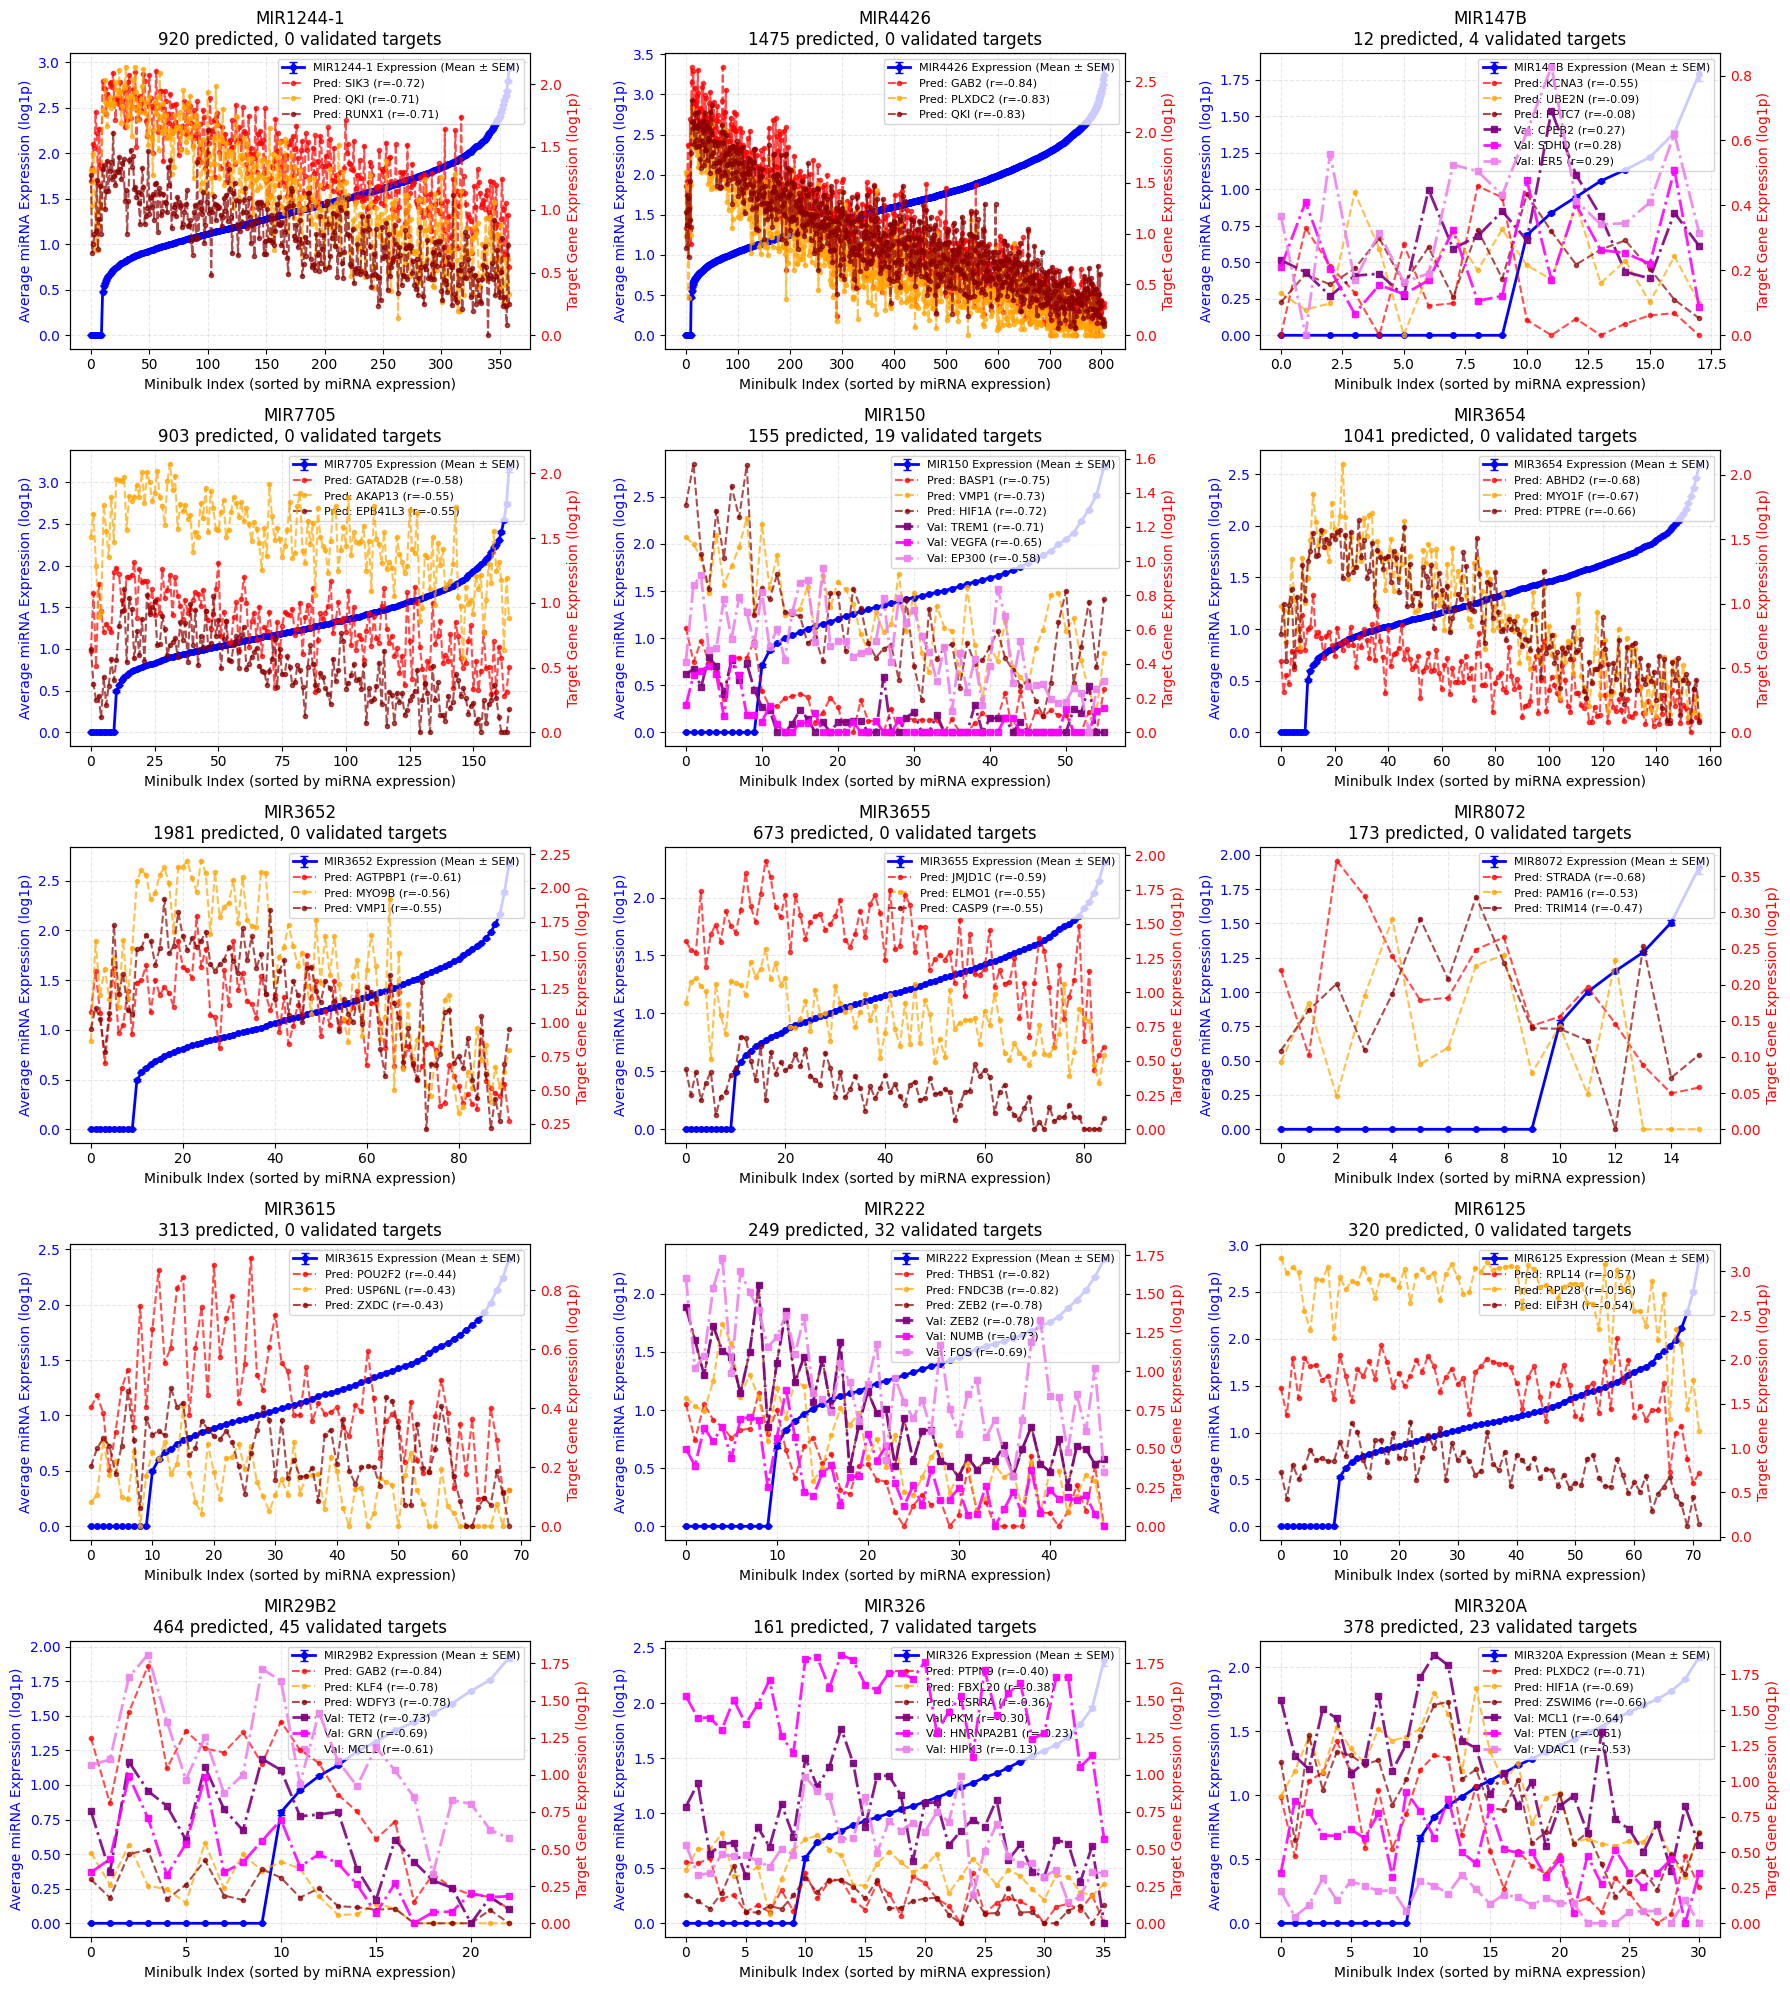


Processing batch 2: miRNAs 16-30
Saved minibulk_plots_batch_2.pdf


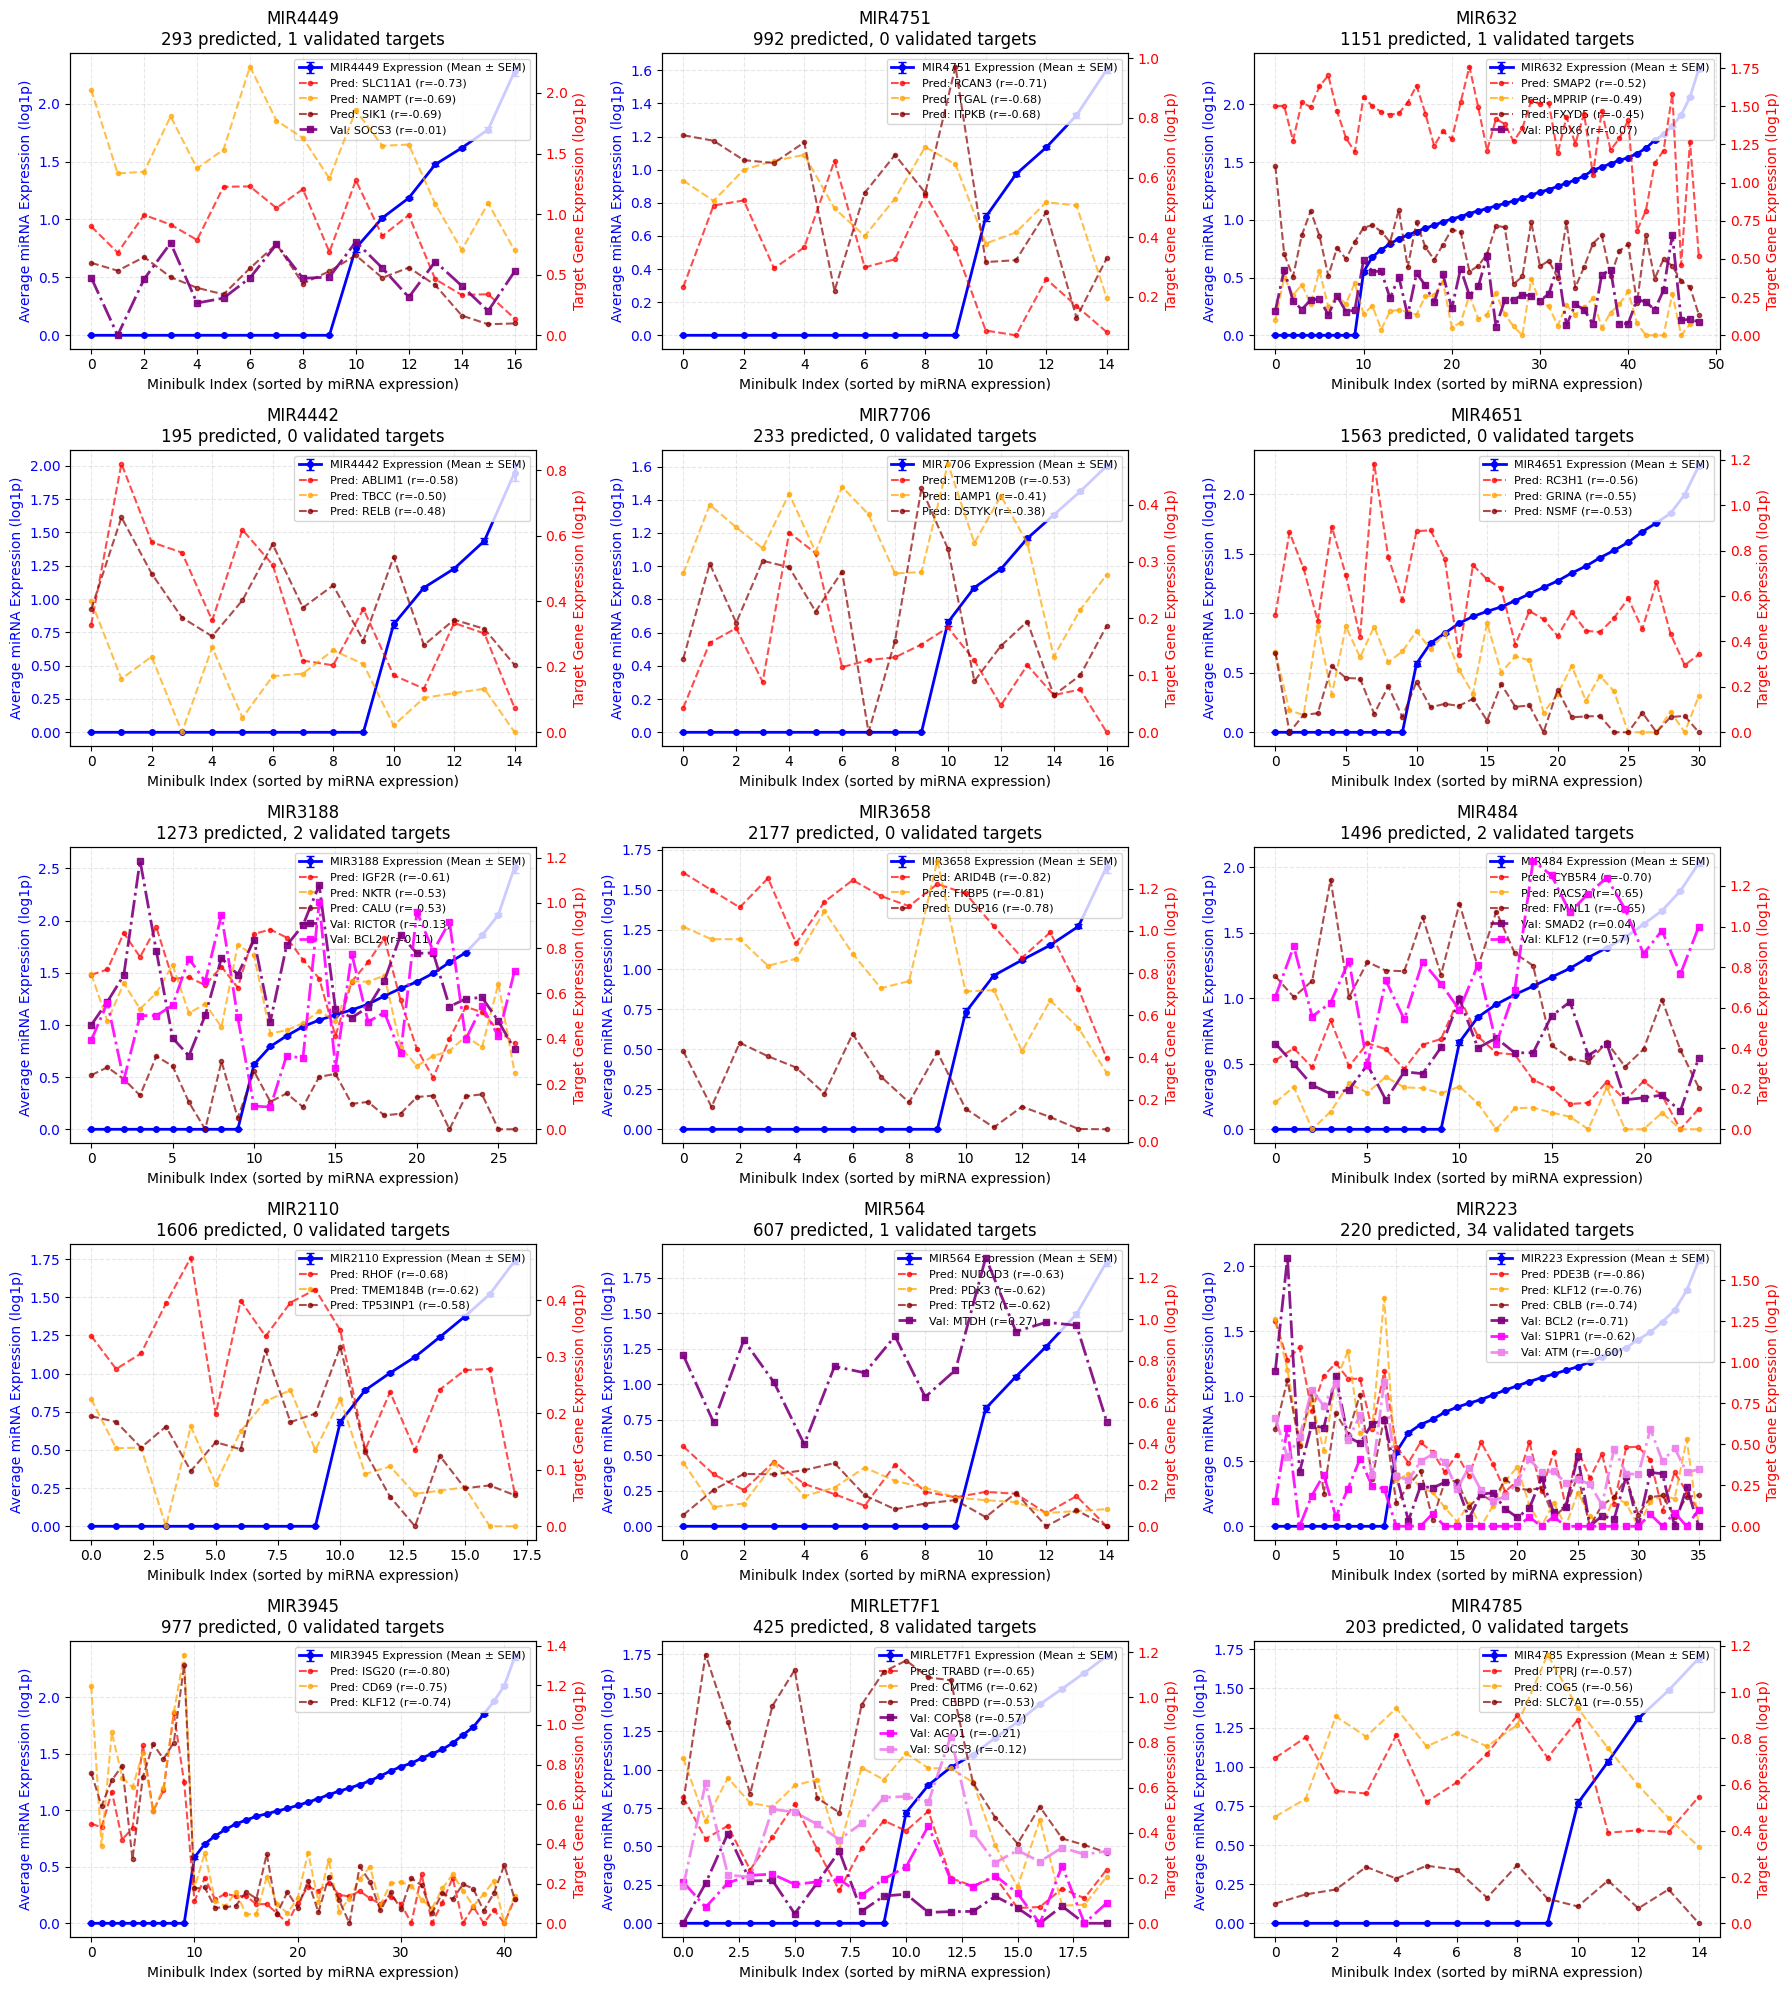


Processing batch 3: miRNAs 31-42
Saved minibulk_plots_batch_3.pdf


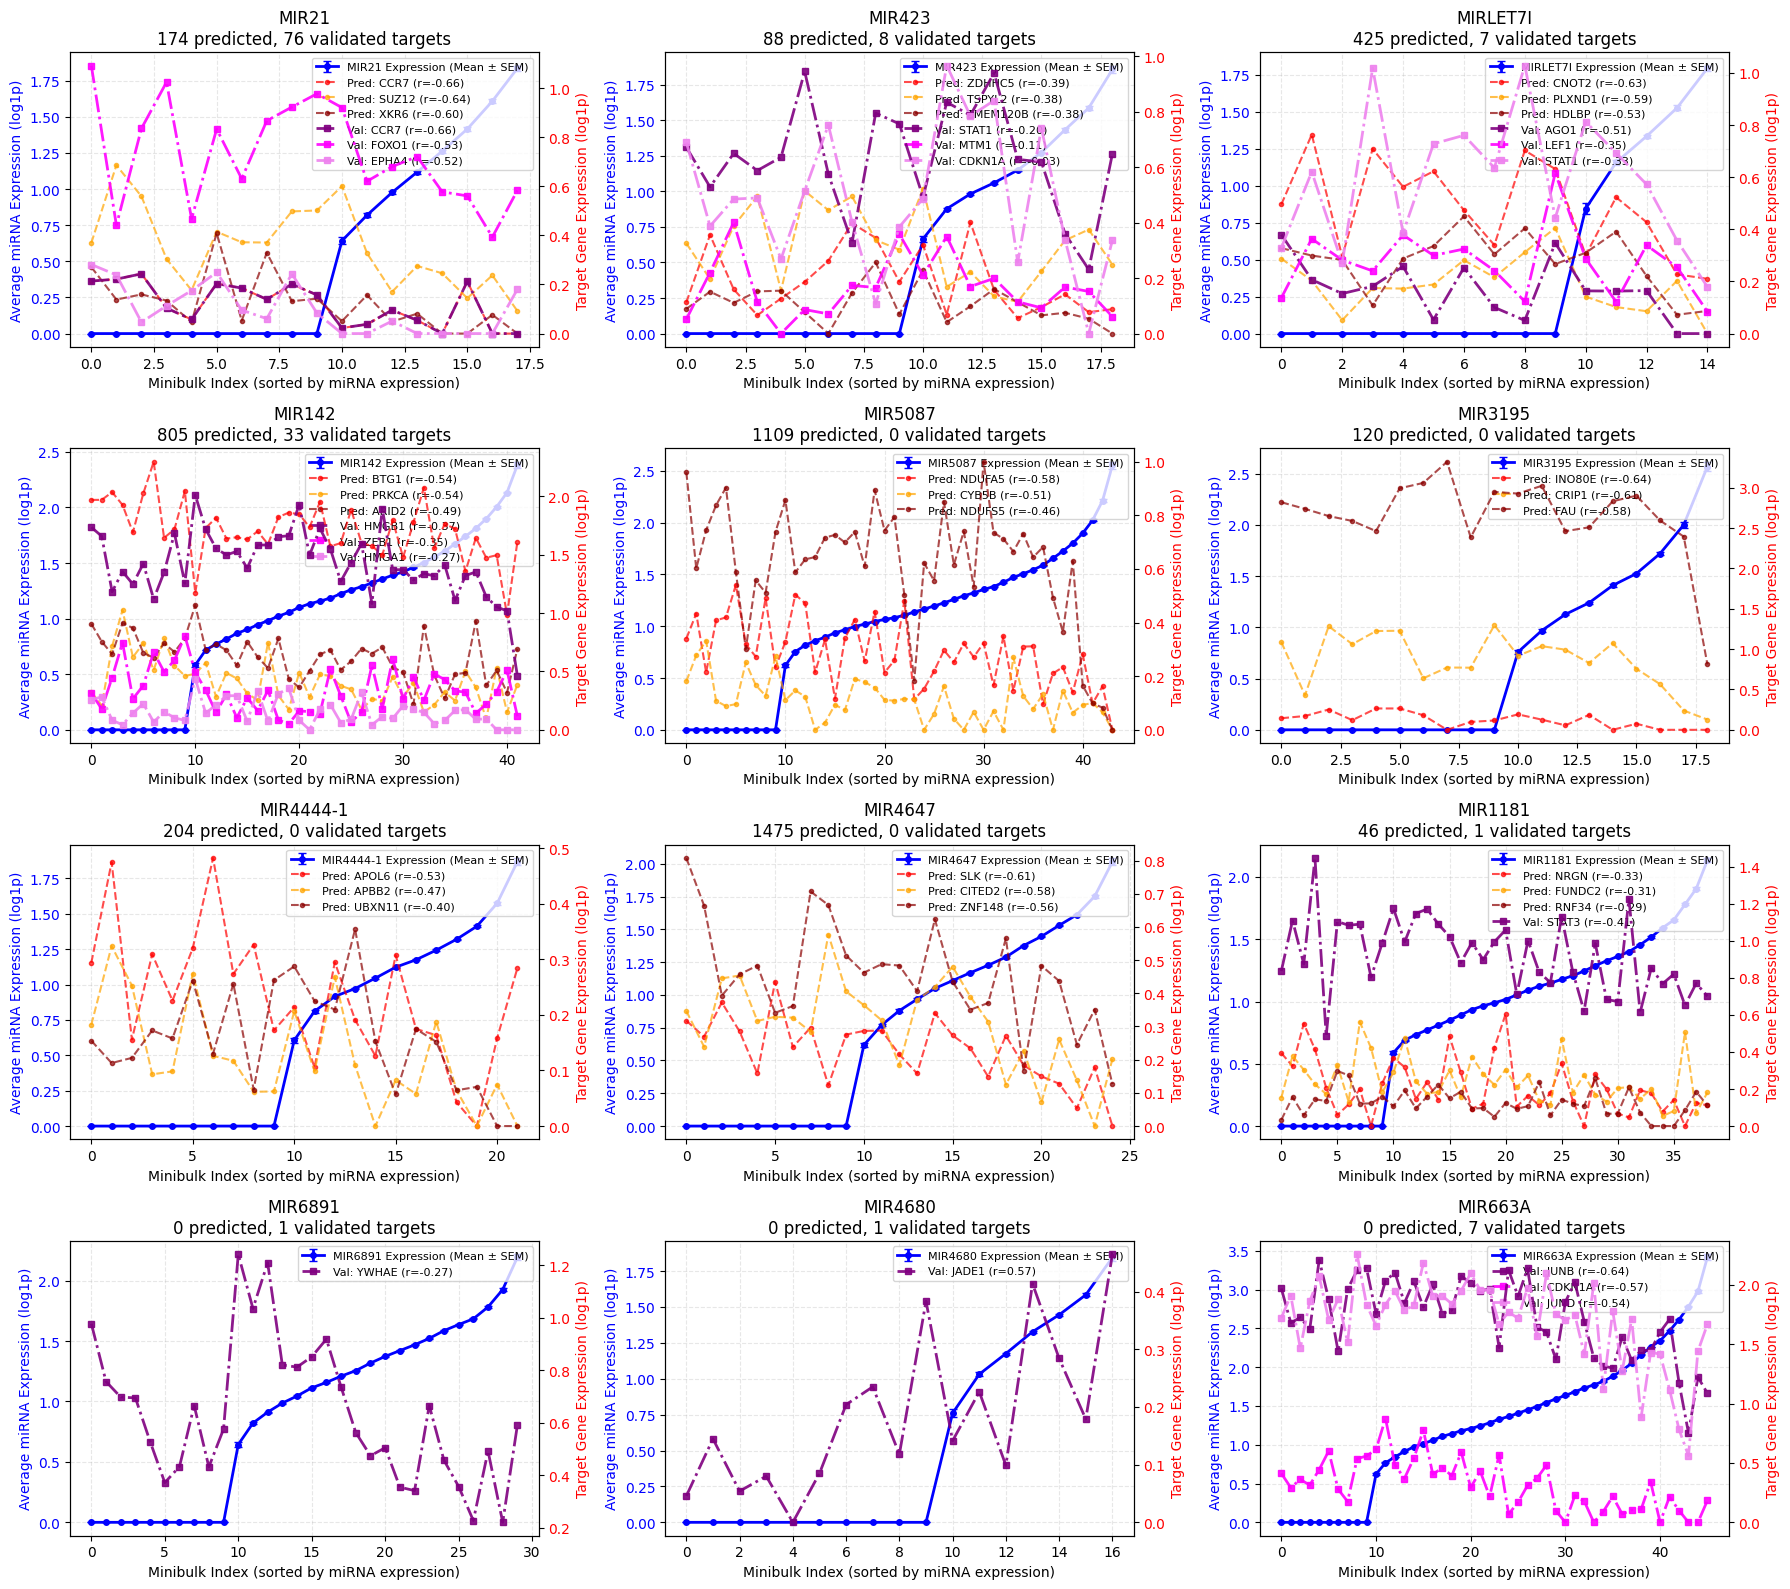


All batches complete! Created 3 PDF files.


In [568]:
# Visualize minibulk behavior for ALL miRNAs with targets (in batches of 15)
import matplotlib.pyplot as plt
import matplotlib.backends.backend_pdf

# Get all miRNAs sorted by KS stat
all_mirnas_sorted = df_results.sort_values("ks_stat", ascending=False)
n_total = len(all_mirnas_sorted)
batch_size = 15

print(f"Plotting {n_total} miRNAs in batches of {batch_size}...")
print(f"Will create {(n_total + batch_size - 1) // batch_size} PDF files")

# Process in batches
for batch_num in range(0, n_total, batch_size):
    batch_end = min(batch_num + batch_size, n_total)
    batch_mirnas = all_mirnas_sorted.iloc[batch_num:batch_end]
    
    print(f"\nProcessing batch {batch_num//batch_size + 1}: miRNAs {batch_num+1}-{batch_end}")
    
    # Create figure for this batch
    n_plots = len(batch_mirnas)
    n_rows = (n_plots + 2) // 3  # Ceiling division for 3 columns
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4*n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]
    
    for plot_idx, (idx, row) in enumerate(batch_mirnas.iterrows()):
        ax = axes[plot_idx]
        mirna = row["mirna"]
        
        # Re-compute minibulks for visualization
        mirna_expr = adata[:, mirna].X
        if sp.issparse(mirna_expr): mirna_expr = mirna_expr.toarray()
        mirna_expr = mirna_expr.flatten()
        
        # Select cells (same logic as correlation analysis)
        expressed_indices = np.where(mirna_expr > 0)[0]
        zero_indices = np.where(mirna_expr == 0)[0]
        if len(zero_indices) > 200:
            np.random.seed(42)
            zero_indices = np.random.choice(zero_indices, 200, replace=False)
        selected_indices = np.concatenate([expressed_indices, zero_indices])
        mirna_expr_sel = mirna_expr[selected_indices]
        sorted_order = np.argsort(mirna_expr_sel)
        sorted_indices = selected_indices[sorted_order]
        
        # Create minibulks
        bulk_size = 20
        n_bulks = len(sorted_indices) // bulk_size
        
        mirna_bulks = []
        mirna_errors = [] # Store standard error of the mean
        coding_bulks = []
        
        for i in range(n_bulks):
            idx_bulk = sorted_indices[i*bulk_size : (i+1)*bulk_size]
            
            # miRNA stats
            bulk_data = mirna_expr[idx_bulk]
            mirna_bulks.append(bulk_data.mean())
            mirna_errors.append(bulk_data.std() / np.sqrt(len(bulk_data))) # SEM
            
            # Coding genes stats (mean only)
            chunk = X_coding[idx_bulk, :].sum(axis=0)
            if hasattr(chunk, "A1"): chunk = chunk.A1
            else: chunk = np.ravel(chunk)
            coding_bulks.append(chunk / bulk_size)
        
        mirna_bulks = np.array(mirna_bulks)
        mirna_errors = np.array(mirna_errors)
        coding_bulks = np.array(coding_bulks)
        
        # Plot miRNA expression across bins with error bars
        ax.errorbar(range(n_bulks), mirna_bulks, yerr=mirna_errors, fmt='o-', 
                    color='blue', linewidth=2, markersize=4, capsize=3, 
                    label=f'{mirna} Expression (Mean ± SEM)')
        
        ax.set_xlabel('Minibulk Index (sorted by miRNA expression)')
        ax.set_ylabel('Average miRNA Expression (log1p)', color='blue')
        ax.tick_params(axis='y', labelcolor='blue')
        ax.grid(True, linestyle='--', alpha=0.3)
        
        # Overlay top anticorrelated targets on secondary axis
        targets = mirna_to_targets.get(mirna, [])
        target_mask = coding_genes.isin(targets)
        
        # Get validated targets
        validated_mask = row.get("validated_mask", np.zeros(len(coding_genes), dtype=bool))
        
        # Compute correlations for this miRNA
        x = mirna_bulks - mirna_bulks.mean()
        Y = coding_bulks - coding_bulks.mean(axis=0)
        x_norm = np.sqrt(np.sum(x**2))
        Y_norm = np.sqrt(np.sum(Y**2, axis=0))
        corrs = (Y.T @ x) / (x_norm * Y_norm + 1e-9)
        
        # Get top 3 most anticorrelated PREDICTED targets
        target_corrs = corrs[target_mask]
        target_names = coding_genes[target_mask]
        
        # Get top 3 most anticorrelated VALIDATED targets
        val_corrs = corrs[validated_mask]
        val_names = coding_genes[validated_mask]
        
        ax2 = ax.twinx()
        
        # Plot Predicted
        if len(target_corrs) > 0:
            top_anticorr_idx = np.argsort(target_corrs)[:3]
            colors = ['red', 'orange', 'darkred']
            for i, gene_idx in enumerate(top_anticorr_idx):
                gene_name = target_names[gene_idx]
                gene_global_idx = coding_genes.get_loc(gene_name)
                gene_expr = coding_bulks[:, gene_global_idx]
                corr = target_corrs[gene_idx]
                ax2.plot(range(n_bulks), gene_expr, 'o--', color=colors[i%len(colors)], 
                        linewidth=1.5, markersize=3, alpha=0.7,
                        label=f'Pred: {gene_name} (r={corr:.2f})')
        
        # Plot Validated
        if len(val_corrs) > 0:
            top_val_idx = np.argsort(val_corrs)[:3]
            val_colors = ['purple', 'magenta', 'violet']
            for i, gene_idx in enumerate(top_val_idx):
                gene_name = val_names[gene_idx]
                gene_global_idx = coding_genes.get_loc(gene_name)
                gene_expr = coding_bulks[:, gene_global_idx]
                corr = val_corrs[gene_idx]
                ax2.plot(range(n_bulks), gene_expr, 's-.', color=val_colors[i%len(val_colors)], 
                        linewidth=2, markersize=4, alpha=0.9,
                        label=f'Val: {gene_name} (r={corr:.2f})')
        
        ax2.set_ylabel('Target Gene Expression (log1p)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
        
        # Combine legends
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
        
        ax.set_title(f'{mirna}\n{len(targets)} predicted, {validated_mask.sum()} validated targets')
    
    # Hide unused subplots
    for plot_idx in range(n_plots, len(axes)):
        axes[plot_idx].set_visible(False)
    
    plt.tight_layout()
    
    # Save this batch as PDF
    pdf_filename = f'minibulk_plots_batch_{batch_num//batch_size + 1}.pdf'
    plt.savefig(pdf_filename, bbox_inches='tight', dpi=150)
    print(f"Saved {pdf_filename}")
    
    plt.show()
    plt.close()

print(f"\nAll batches complete! Created {(n_total + batch_size - 1) // batch_size} PDF files.")


Global Summary Plot

In [570]:
# --- Sankey Diagram of Analysis Flow ---
import plotly.graph_objects as go

# 1. Calculate Statistics
n_annotated = len(adata.var[adata.var['biotype'] == 'miRNA'])
n_expressed = len(keep_mirnas)
n_with_pred = len(df_results)

# Validated stats
mask_val = df_results['n_validated'] > 0
n_with_val = mask_val.sum()
n_only_pred = n_with_pred - n_with_val

# Interaction stats - Split by group into 3 categories
# Group A: Validated
n_interactions_val = df_results[mask_val]['n_targets'].sum()
n_neg_val = int((df_results[mask_val]['frac_neg_corr'] * df_results[mask_val]['n_targets']).sum())
n_pos_val = int((df_results[mask_val]['frac_pos_corr'] * df_results[mask_val]['n_targets']).sum())
n_uncorr_val = n_interactions_val - n_neg_val - n_pos_val

# Group B: Only Predicted
n_interactions_pred = df_results[~mask_val]['n_targets'].sum()
n_neg_pred = int((df_results[~mask_val]['frac_neg_corr'] * df_results[~mask_val]['n_targets']).sum())
n_pos_pred = int((df_results[~mask_val]['frac_pos_corr'] * df_results[~mask_val]['n_targets']).sum())
n_uncorr_pred = n_interactions_pred - n_neg_pred - n_pos_pred

# Total interactions (for scaling check)
n_interactions_total = n_interactions_val + n_interactions_pred

print(f"\nSankey Diagram Statistics:")
print(f"  Total miRNAs with targets: {n_with_pred}")
print(f"  Total target interactions: {n_interactions_total}")
print(f"  Validated interactions: {n_interactions_val}")
print(f"  Predicted-only interactions: {n_interactions_pred}")
print(f"\nCorrelation breakdown (|r|>0.2, p<0.05):")
print(f"  Validated - Negative: {n_neg_val}, Positive: {n_pos_val}, Uncorrelated: {n_uncorr_val}")
print(f"  Predicted - Negative: {n_neg_pred}, Positive: {n_pos_pred}, Uncorrelated: {n_uncorr_pred}")

# 2. Define Visual Scaling
# Scale interaction counts to match the visual width of miRNA counts
scale_factor = n_with_pred / n_interactions_total if n_interactions_total > 0 else 1

# 3. Define Nodes (now with 3 correlation categories)
labels = [
    f"Annotated miRNAs<br>(after scanpy default QC)<br>({n_annotated})",           # 0
    f"Expressed miRNAs<br>(>2% cells/cell type)<br>(in >100 cells overall)<br>({n_expressed})",           # 1
    f"miRNAs with Expressed<br>Targets<br>({n_with_pred})",# 2
    f"with Validated<br>Targets<br>({n_with_val})", # 3
    f"with Only<br>Predicted Targets<br>({n_only_pred})",   # 4
    
    f"Validated Target<br>Interactions<br>({n_interactions_val})",      # 5
    f"Predicted Target<br>Interactions<br>({n_interactions_pred})",    # 6
    
    f"Val Neg Corr<br>({n_neg_val})",           # 7
    f"Val Pos Corr<br>({n_pos_val})",           # 8
    f"Val<br>Uncorr<br>({n_uncorr_val})",          # 9
    
    f"Pred Neg<br>Corr<br>({n_neg_pred})",         # 10
    f"Pred Pos<br>Corr<br>({n_pos_pred})",         # 11
    f"Pred<br>Uncorrelated<br>({n_uncorr_pred})"         # 12
]

colors = [
    "#1f77b4", # Annot (Blue)
    "#2ca02c", # Expr (Green)
    "#ff7f0e", # Pred (Orange)
    
    "#9467bd", # Val Group (Purple)
    "#ffbb78", # Only Pred Group (Light Orange)
    
    "#c5b0d5", # Val Interactions (Light Purple)
    "#fdbf6f", # Pred Interactions (Light Orange)
    
    "#1f77b4", # Val Neg (Red)
    "#d62728", # Val Pos (Green)
    "#808080", # Val Uncorr (Gray)
    
    "#1f77b4", # Pred Neg (Light Red)
    "#d62728", # Pred Pos (Light Green)
    "#c7c7c7"  # Pred Uncorr (Light Gray)
]

# 4. Define Links
source = [
    0, 1, 2, 2, 
    3, 4, 
    5, 5, 5,
    6, 6, 6
]
target = [
    1, 2, 3, 4, 
    5, 6, 
    7, 8, 9,
    10, 11, 12
]
value = [
    n_expressed,                # Annot -> Expr
    n_with_pred,                # Expr -> Pred
    n_with_val,                 # Pred -> Val
    n_only_pred,                # Pred -> Only Pred
    
    n_interactions_val * scale_factor,   # Val -> Val Interactions
    n_interactions_pred * scale_factor,  # Only Pred -> Pred Interactions
    
    n_neg_val * scale_factor,            # Val Int -> Neg
    n_pos_val * scale_factor,            # Val Int -> Pos
    n_uncorr_val * scale_factor,         # Val Int -> Uncorr
    
    n_neg_pred * scale_factor,           # Pred Int -> Neg
    n_pos_pred * scale_factor,           # Pred Int -> Pos
    n_uncorr_pred * scale_factor         # Pred Int -> Uncorr
]

# 5. Create Sankey
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color=colors
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(
    title_text="miRNA Analysis Flow (Expressed Targets: >1% cells & mean>0.1, |r|>0.2, p<0.05)",
    font_size=10,
    height=600
)

fig.show()

# Save as PDF (with fallback to HTML)
try:
    # Try kaleido first
    import kaleido
    fig.write_image("sankey_diagram.pdf", width=1200, height=800, engine="kaleido")
    print("Sankey diagram saved as sankey_diagram.pdf (using kaleido)")
except ImportError:
    try:
        # Fallback to orca
        fig.write_image("sankey_diagram.pdf", width=1200, height=800, engine="orca")
        print("Sankey diagram saved as sankey_diagram.pdf (using orca)")
    except Exception as e2:
        # Last resort: save as HTML
        fig.write_html("sankey_diagram.html")
        print(f"Saved as HTML instead: sankey_diagram.html")
        print(f"PDF export failed: {e2}")
except Exception as e:
    try:
        # Save as HTML as fallback
        fig.write_html("sankey_diagram.html")
        print(f"Saved as HTML instead: sankey_diagram.html")
        print(f"PDF export error: {e}")
    except Exception as e2:
        print(f"Could not save diagram: {e2}")



Sankey Diagram Statistics:
  Total miRNAs with targets: 42
  Total target interactions: 27075
  Validated interactions: 8422
  Predicted-only interactions: 18653

Correlation breakdown (|r|>0.2, p<0.05):
  Validated - Negative: 976, Positive: 300, Uncorrelated: 7146
  Predicted - Negative: 4110, Positive: 961, Uncorrelated: 13582


Saved as HTML instead: sankey_diagram.html
PDF export error: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

